# O1 fixed-100-tree Mistral policy comparison

This notebook compares two RWTHGPT Mistral policies with the original compact
LLM policy and the 100-tree fixed-depth controls from `40_02_different_dimensions`.
Both Mistral policies fix `n_trees=100`; Mistral chooses only maximum depth,
split and leaf sizes, and feature ratio. One receives the original compact
ten-window summary, while the other receives every second completed trial with
its configuration and proposal-time SMAC diagnostics.

Lower objective values are better. The legacy experiment has no 10D compact or
100-tree fixed-depth reference data; the coverage table leaves that gap visible.

In [6]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
HERE = Path.cwd()
if HERE.name != '40_04_mistral':
    HERE = Path('experiments/synthaticBench/o1_deterministic/depth_policies/40_04_mistral').resolve()
NEW_ROOT = HERE / 'results'
LEGACY_ROOT = HERE.parent / '40_02_different_dimensions' / 'results'
DIMENSIONS = (10, 25, 50, 100)
SEEDS = tuple(range(5))
DEPTHS = (5, 10, 15, 20, 30)
N_TRIALS = 1000
NEW_POLICIES = {
    'Compact LLM Mistral (100 trees)': 'rwthgpt_mistral_compact_fixed_100_trees',
    'Every-second Mistral (100 trees)': 'rwthgpt_mistral_every_second_fixed_100_trees',
}
LEGACY_COMPACT = 'openai_compact_llm_rf_policy'
print(f'New results: {NEW_ROOT}')
print(f'Legacy results: {LEGACY_ROOT}')

New results: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/40_04_mistral/results
Legacy results: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/40_02_different_dimensions/results


## Load and coverage

Only complete 1,000-trial trajectories are included in rankings and plots.
`missing` means that no trajectory exists; `running` means a completion marker
exists but the run has not yet written its trajectory.

In [7]:
def new_path(policy_name, dimension, seed):
    return NEW_ROOT / f'dimension_{dimension}' / 'benchmark_seed_40' / policy_name / str(seed)

def legacy_path(policy_name, dimension, seed):
    return LEGACY_ROOT / f'dimension_{dimension}' / 'benchmark_seed_40' / policy_name / str(seed)

specifications = [
    *[(label, name, 'mistral') for label, name in NEW_POLICIES.items()],
    ('Compact LLM original', LEGACY_COMPACT, 'legacy'),
    *[(f'Fixed depth {depth} (100 trees)', f'fixed_depth_{depth}_100_trees', 'legacy') for depth in DEPTHS],
]
runs = []
for dimension in DIMENSIONS:
    for label, name, source in specifications:
        for seed in SEEDS:
            directory = (new_path if source == 'mistral' else legacy_path)(name, dimension, seed)
            trajectory_path = directory / 'trajectory.json'
            completion_path = directory / 'completed.json'
            payload = json.loads(trajectory_path.read_text()) if trajectory_path.exists() else None
            completion = json.loads(completion_path.read_text()) if completion_path.exists() else {}
            status = 'complete' if payload else completion.get('state', 'missing')
            best = [] if payload is None else payload.get('best_so_far', [])
            runs.append(dict(dimension=dimension, policy=label, source=source, smac_seed=seed,
                             status=status, trials=0 if payload is None else len(payload.get('iteration', [])),
                             final=np.nan if not best else float(best[-1]), payload=payload,
                             directory=str(directory)))
coverage = pd.DataFrame(runs)
display(coverage.drop(columns='payload').sort_values(['dimension', 'policy', 'smac_seed']))
display(coverage.groupby(['dimension', 'policy', 'status']).size().rename('runs').reset_index())

,dimension,policy,source,smac_seed,status,trials,final,directory
0,10,Compact LLM Mistral (100 trees),mistral,0,complete,1000,-2.218371e+05,/rwthfs/rz/cluster/home/io632776/experiments/a...
1,10,Compact LLM Mistral (100 trees),mistral,1,complete,1000,-2.219697e+05,/rwthfs/rz/cluster/home/io632776/experiments/a...
2,10,Compact LLM Mistral (100 trees),mistral,2,complete,1000,-2.195918e+05,/rwthfs/rz/cluster/home/io632776/experiments/a...
3,10,Compact LLM Mistral (100 trees),mistral,3,complete,1000,-2.227790e+05,/rwthfs/rz/cluster/home/io632776/experiments/a...
4,10,Compact LLM Mistral (100 trees),mistral,4,complete,1000,-2.180810e+05,/rwthfs/rz/cluster/home/io632776/experiments/a...
...,...,...,...,...,...,...,...,...
135,100,Fixed depth 5 (100 trees),legacy,0,complete,1000,-1.321343e+06,/rwthfs/rz/cluster/home/io632776/experiments/a...
136,100,Fixed depth 5 (100 trees),legacy,1,complete,1000,-1.161106e+06,/rwthfs/rz/cluster/home/io632776/experiments/a...
137,100,Fixed depth 5 (100 trees),legacy,2,complete,1000,-1.291761e+06,/rwthfs/rz/cluster/home/io632776/experiments/a...
138,100,Fixed depth 5 (100 trees),legacy,3,complete,1000,-1.176737e+06,/rwthfs/rz/cluster/home/io632776/experiments/a...


,dimension,policy,status,runs
0,10,Compact LLM Mistral (100 trees),complete,5
1,10,Compact LLM original,missing,5
2,10,Every-second Mistral (100 trees),complete,5
3,10,Fixed depth 10 (100 trees),missing,5
4,10,Fixed depth 15 (100 trees),missing,5
5,10,Fixed depth 20 (100 trees),missing,5
6,10,Fixed depth 30 (100 trees),missing,5
7,10,Fixed depth 5 (100 trees),missing,5
8,25,Compact LLM Mistral (100 trees),complete,5
9,25,Compact LLM original,complete,5


## Mean optimization trajectories

Lines are mean best-so-far objective values over the completed SMAC seeds.
Shading is ± one standard error; a policy is omitted until it has a complete
trajectory.

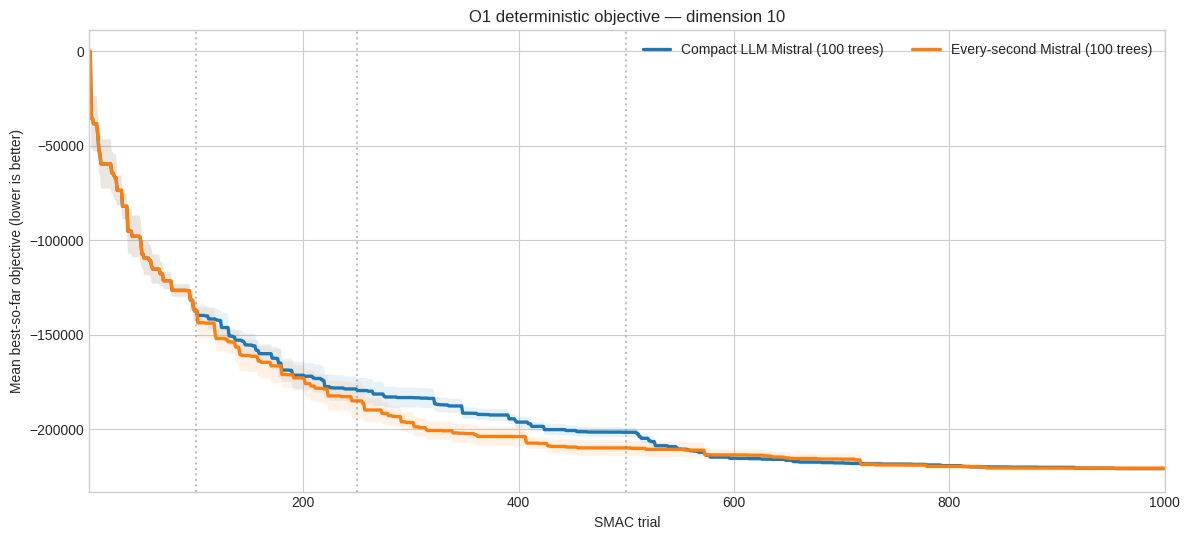

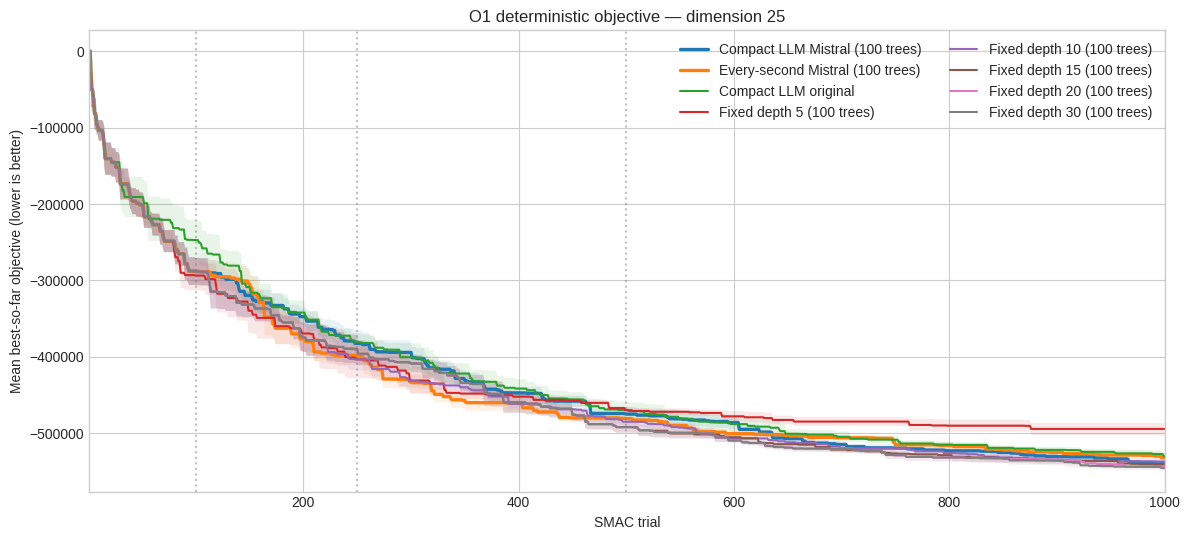

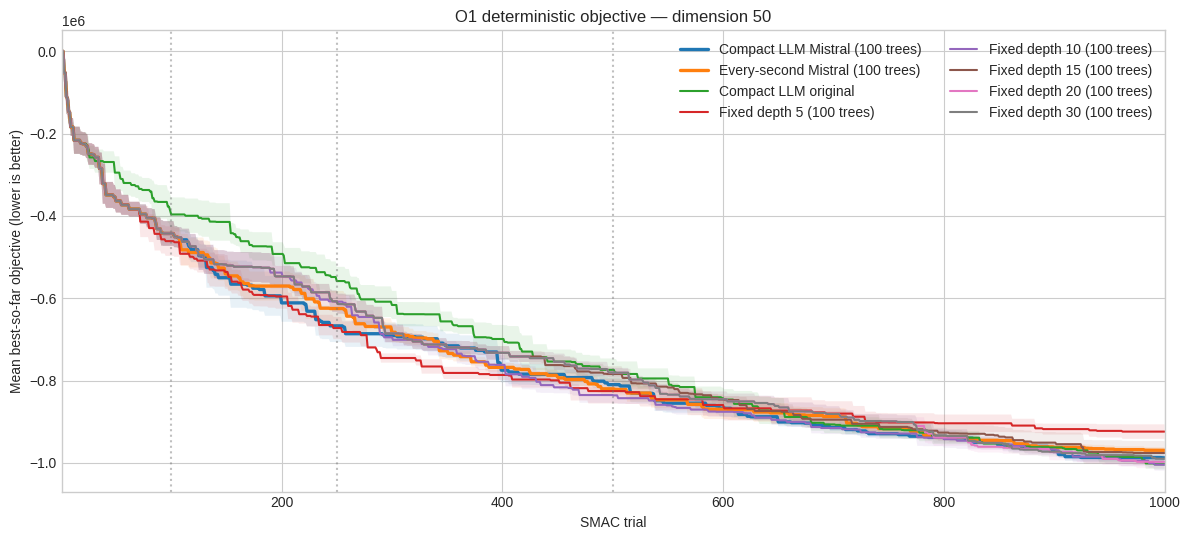

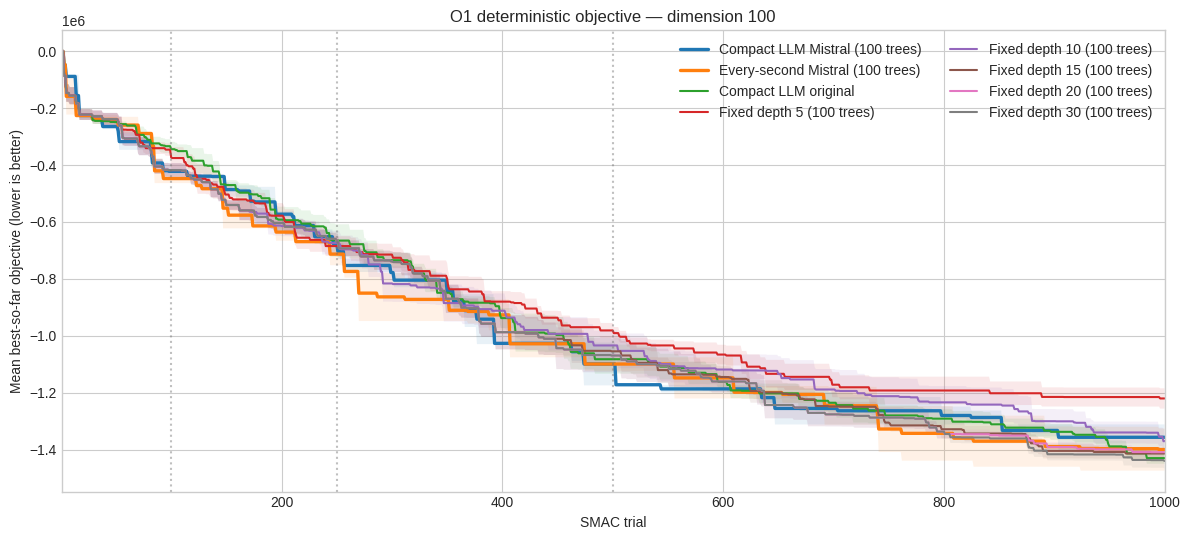

In [8]:
complete = coverage[(coverage.status == 'complete') & (coverage.trials == N_TRIALS)].copy()
for dimension in DIMENSIONS:
    fig, ax = plt.subplots(figsize=(12, 5.5))
    plotted = False
    for label, _, _ in specifications:
        selected = complete[(complete.dimension == dimension) & (complete.policy == label)]
        curves = [np.asarray(row.payload['best_so_far'], dtype=float) for row in selected.itertuples()]
        if not curves:
            continue
        length = min(map(len, curves))
        values = np.vstack([curve[:length] for curve in curves])
        mean = values.mean(axis=0)
        se = values.std(axis=0, ddof=1) / math.sqrt(len(values)) if len(values) > 1 else np.zeros(length)
        x = np.arange(1, length + 1)
        ax.plot(x, mean, label=label, linewidth=2.4 if 'Mistral' in label else 1.5)
        ax.fill_between(x, mean-se, mean+se, alpha=.10)
        plotted = True
    for checkpoint in (100, 250, 500): ax.axvline(checkpoint, color='0.45', linestyle=':', alpha=.45)
    ax.set(title=f'O1 deterministic objective — dimension {dimension}', xlabel='SMAC trial',
           ylabel='Mean best-so-far objective (lower is better)', xlim=(1, N_TRIALS))
    if plotted: ax.legend(ncol=2)
    else: ax.text(.5, .5, 'No complete trajectories yet', ha='center', va='center', transform=ax.transAxes)
    plt.tight_layout(); plt.show()

## Final-incumbent ranking

Policies are ranked independently within each objective dimension by their
mean final incumbent over complete runs. The last table averages ranks only
over dimensions where a policy has data.

In [9]:
ranking = (complete.groupby(['dimension', 'policy'])
           .agg(average_final=('final', 'mean'), std_final=('final', 'std'), runs=('final', 'size'))
           .reset_index())
if len(ranking):
    ranking['rank'] = ranking.groupby('dimension')['average_final'].rank(method='min', ascending=True).astype(int)
    ranking = ranking.sort_values(['dimension', 'rank', 'policy'])
    display(ranking)
    display(ranking.groupby('policy').agg(average_rank=('rank', 'mean'), dimensions_ranked=('dimension', 'nunique'))
            .reset_index().sort_values(['average_rank', 'policy']))
else:
    print('No complete trajectories yet.')

,dimension,policy,average_final,std_final,runs,rank
0,10,Compact LLM Mistral (100 trees),-2.208517e+05,1949.352677,5,1
1,10,Every-second Mistral (100 trees),-2.206019e+05,2837.175849,5,2
8,25,Fixed depth 30 (100 trees),-5.456738e+05,7371.476509,5,1
7,25,Fixed depth 20 (100 trees),-5.438382e+05,6035.596695,5,2
6,25,Fixed depth 15 (100 trees),-5.409704e+05,8692.837147,5,3
2,25,Compact LLM Mistral (100 trees),-5.400405e+05,7844.413514,5,4
5,25,Fixed depth 10 (100 trees),-5.370213e+05,8551.693579,5,5
4,25,Every-second Mistral (100 trees),-5.318158e+05,13202.165916,5,6
3,25,Compact LLM original,-5.306122e+05,10960.055172,5,7
9,25,Fixed depth 5 (100 trees),-4.943786e+05,17868.848570,5,8


,policy,average_rank,dimensions_ranked
6,Fixed depth 30 (100 trees),2.000000,3
5,Fixed depth 20 (100 trees),3.000000,3
1,Compact LLM original,3.666667,3
3,Fixed depth 10 (100 trees),4.000000,3
4,Fixed depth 15 (100 trees),4.000000,3
0,Compact LLM Mistral (100 trees),4.250000,4
2,Every-second Mistral (100 trees),5.000000,4
7,Fixed depth 5 (100 trees),8.000000,3


## Final incumbent boxplots

Each box shows the distribution of final incumbent performance across SMAC
seeds for one dimension and policy. Points are the individual seeds; lower is
better. Policies without complete trajectories are omitted automatically.

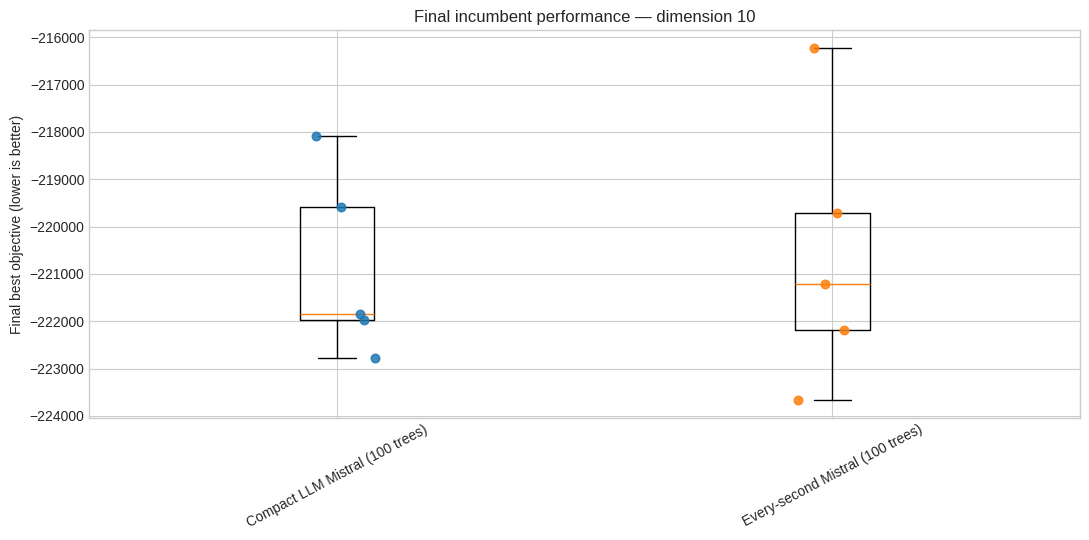

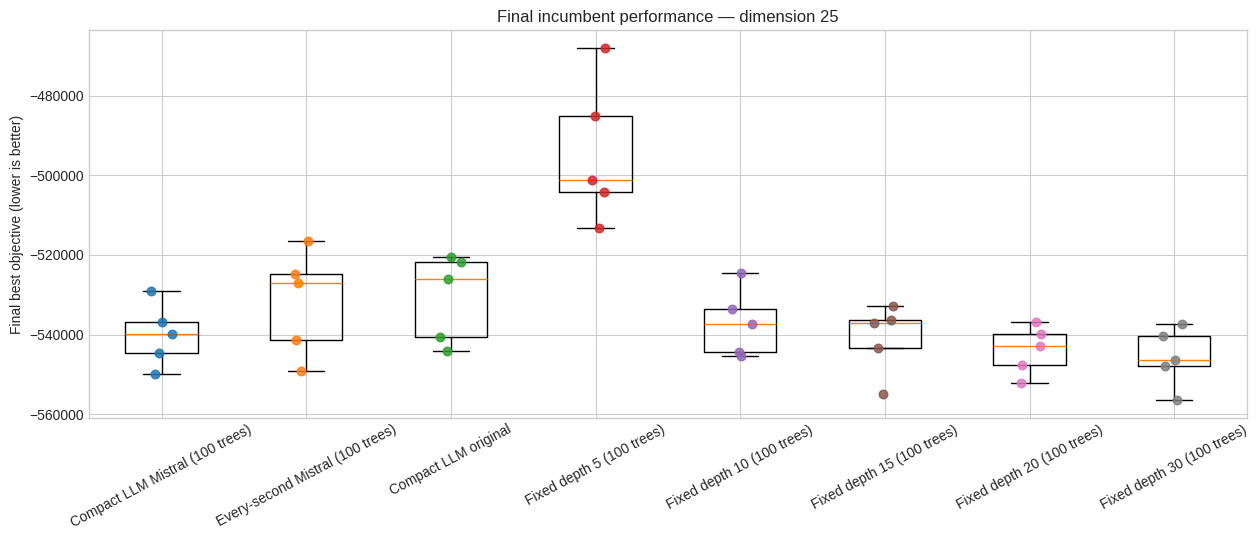

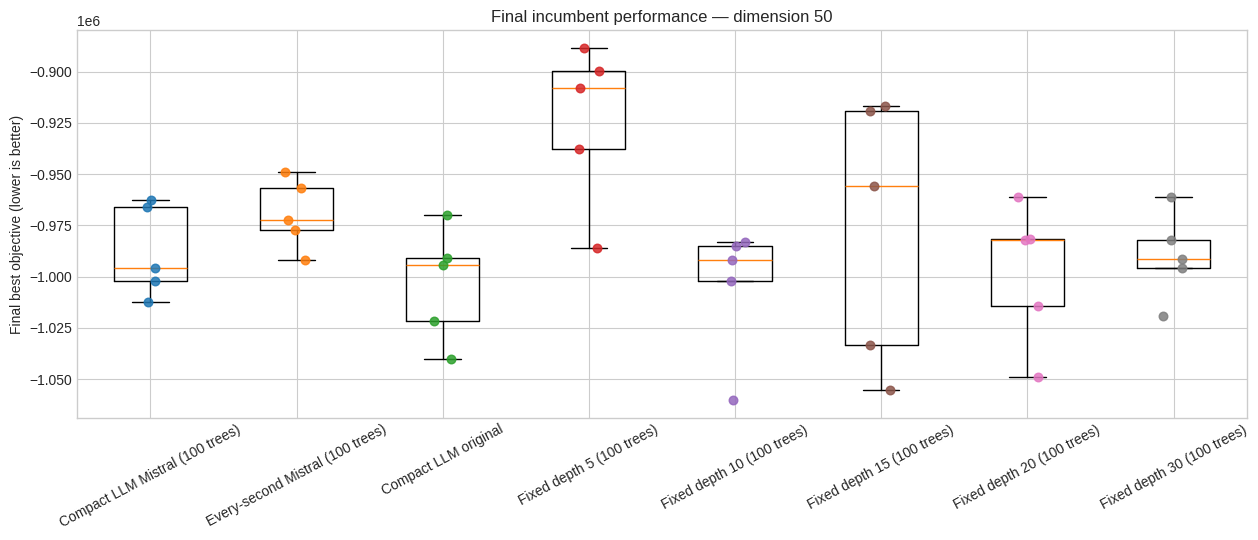

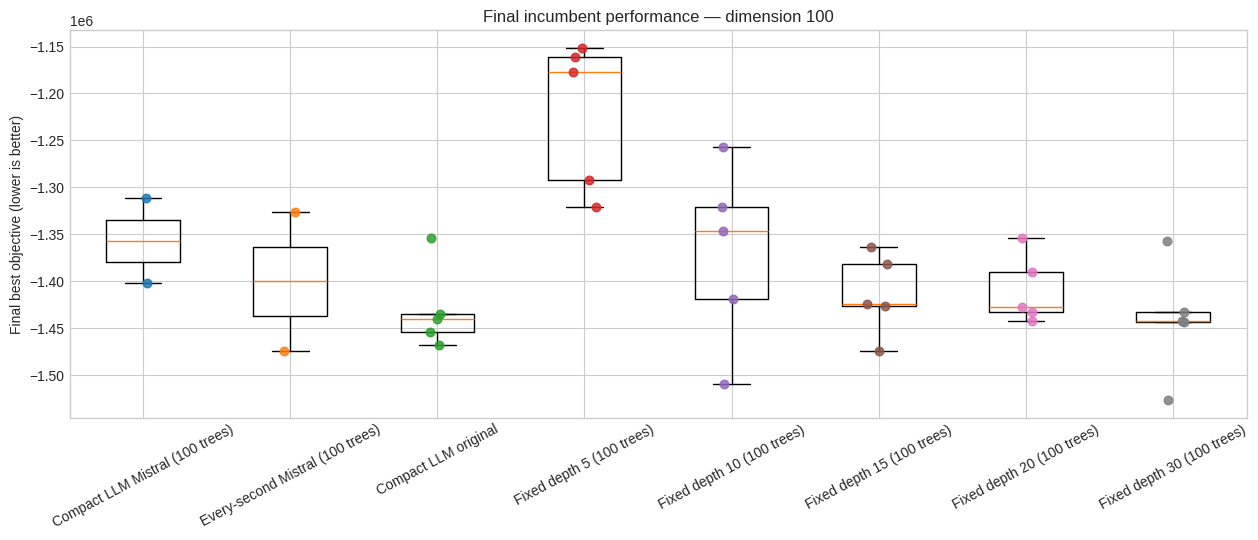

In [10]:
for dimension in DIMENSIONS:
    part = complete[complete.dimension == dimension]
    available = [label for label, _, _ in specifications if (part.policy == label).any()]
    if not available:
        print(f'No complete trajectories for dimension {dimension}.')
        continue
    values = [part.loc[part.policy == label, 'final'].to_numpy(dtype=float) for label in available]
    fig, ax = plt.subplots(figsize=(max(11, 1.6 * len(available)), 5.5))
    ax.boxplot(values, tick_labels=available, showfliers=False)
    rng = np.random.default_rng(40 + dimension)
    for index, sample in enumerate(values, 1):
        jitter = rng.uniform(-0.08, 0.08, size=len(sample))
        ax.scatter(index + jitter, sample, s=38, alpha=0.85, zorder=3)
    ax.set_title(f'Final incumbent performance — dimension {dimension}')
    ax.set_ylabel('Final best objective (lower is better)')
    ax.tick_params(axis='x', rotation=28)
    plt.tight_layout(); plt.show()

## Mistral decisions, prompt size, and retries

The decision table audits that `n_trees` remained fixed at 100. It also shows
the actual checkpoint trigger, input-token estimate, and any 15-second
rate-limit retries. The every-second policy should have substantially larger
inputs than the compact-summary policy.

In [11]:
decision_rows = []
for row in coverage[coverage.source == 'mistral'].itertuples():
    payload = row.payload
    if payload is None:
        continue
    for checkpoint, decision in payload.get('llm_policy', {}).get('decisions', {}).items():
        settings = decision.get('settings', {})
        metadata = decision.get('usage') or {}
        request_path = Path(row.directory) / 'llm_requests' / f'checkpoint_{int(checkpoint):04d}' / 'openai_response_metadata.json'
        request_metadata = json.loads(request_path.read_text()) if request_path.exists() else {}
        decision_rows.append(dict(dimension=row.dimension, policy=row.policy, smac_seed=row.smac_seed,
            checkpoint=int(checkpoint), actual_completed_trials=decision.get('actual_completed_trials_at_call'),
            n_trees=settings.get('n_trees'), max_depth=settings.get('max_depth'),
            min_samples_split=settings.get('min_samples_split'), min_samples_leaf=settings.get('min_samples_leaf'),
            feature_ratio=settings.get('feature_ratio'), confidence=decision.get('confidence'),
            prompt_token_estimate=request_metadata.get('input_token_estimate'),
            rate_limit_retries=request_metadata.get('rate_limit_retries'),
            input_tokens=metadata.get('prompt_tokens'), output_tokens=metadata.get('completion_tokens'),
            reason=decision.get('reason')))
decisions = pd.DataFrame(decision_rows)
if len(decisions):
    assert decisions.n_trees.eq(100).all(), 'A model decision changed n_trees.'
    with pd.option_context('display.max_colwidth', 240, 'display.max_rows', None):
        display(decisions.sort_values(['dimension', 'policy', 'smac_seed', 'checkpoint']))
    display(decisions.groupby(['policy', 'checkpoint'])[['prompt_token_estimate', 'rate_limit_retries', 'input_tokens', 'output_tokens']].mean().round(1))
else:
    print('No completed Mistral decisions yet.')

,dimension,policy,smac_seed,checkpoint,actual_completed_trials,n_trees,max_depth,min_samples_split,min_samples_leaf,feature_ratio,confidence,prompt_token_estimate,rate_limit_retries,input_tokens,output_tokens,reason
0,10,Compact LLM Mistral (100 trees),0,100,107,100,20,3,1,0.500000,0.95,6026,0,13945,82,Decrease feature_ratio to mitigate overfitting while keeping max_depth high due to stable performance. min_samples_leaf=1 balances under-/overfitting.
1,10,Compact LLM Mistral (100 trees),0,250,250,100,25,3,1,0.500000,0.90,14539,0,34633,73,Bug behavior observed: high proxy error suggests overfitting. Increasing max_depth may reduce variance while maintaining low leaf size.
2,10,Compact LLM Mistral (100 trees),0,500,500,100,15,2,1,0.600000,0.78,28704,0,69078,87,High relative proxy errors in current settings suggest overfitting; decreasing max_depth to reduce variance while keeping split/leaf ratios low to capture better generalization with slightly higher feature ratio for diversity.
3,10,Compact LLM Mistral (100 trees),1,100,101,100,15,4,2,0.600000,0.95,6049,0,14051,69,High proxy errors suggest overfitting; reducing depth and increasing split/leaf samples improves generalization.
4,10,Compact LLM Mistral (100 trees),1,250,258,100,12,6,3,0.800000,0.87,14561,0,34738,66,Balancing tree depth and leaf constraints to reduce overfitting observed in recent predictions
5,10,Compact LLM Mistral (100 trees),1,500,505,100,15,4,2,0.600000,0.95,28806,0,69502,68,Strong performance in recent checkpoints. Low min_samples values improve generalization with observed proxy errors.
6,10,Compact LLM Mistral (100 trees),2,100,108,100,10,5,2,0.500000,0.85,6061,0,14099,85,Moderate depth and split/leaf ratios to balance bias-variance; halved feature ratio to reduce overfitting based on high absolute_proxy_error in current runs.
7,10,Compact LLM Mistral (100 trees),2,250,259,100,20,2,1,0.700000,0.88,14536,0,34636,79,increased feature exploration to 0.7 and shallower trees to improve general predictive accuracy and reduce overfitting based on observed large proxy errors
8,10,Compact LLM Mistral (100 trees),2,500,500,100,15,3,1,0.800000,0.75,28666,0,68941,71,Reducing max_depth and min_samples_split to improve surrogate model fit; increasing feature_ratio for more global exploration
9,10,Compact LLM Mistral (100 trees),3,100,104,100,15,4,2,0.500000,0.85,6061,0,14100,72,"Balanced random-forest parameters to reduce overfitting while maintaining predictive stability, given observed high proxy errors."


prompt_token_estimate  \
policy                           checkpoint                          
Compact LLM Mistral (100 trees)  100                       11776.3   
                                 250                       29018.6   
                                 500                       57788.9   
Every-second Mistral (100 trees) 100                       11753.7   
                                 250                       28999.1   
                                 500                       57726.4   

                                             rate_limit_retries  input_tokens  \
policy                           checkpoint                                     
Compact LLM Mistral (100 trees)  100                        0.1       34277.6   
                                 250                        0.4       85868.6   
                                 500                        0.2      172043.8   
Every-second Mistral (100 trees) 100                        0.5       34187.2   
                                 250                        1.2       85790.8   
                                 500                        1.6      171793.6   

                                             output_tokens  
policy                           checkpoint                 
Compact LLM Mistral (100 trees)  100                  75.9  
                                 250                  75.8  
                                 500                  76.5  
Every-second Mistral (100 trees) 100                  76.1  
                                 250                  71.9  
                                 500                  77.8